In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df1=pd.read_csv('heart.csv')

In [5]:
df1.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Performing EDA & Data Cleaning

In [6]:
df1.shape

(918, 12)

In [7]:
df1.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [8]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [9]:
df1.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [10]:
df1.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [11]:
df1.duplicated().sum()

np.int64(0)

In [12]:
df1['HeartDisease'].value_counts()   # mostly equally distributed which is  a good thing  

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [13]:
df1.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [14]:
df1['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [15]:
df1['Sex']=df1['Sex'].map({'M':0,'F':1})

Seeing the continuous data by plotting graphs

In [16]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df1[var],kde=True)


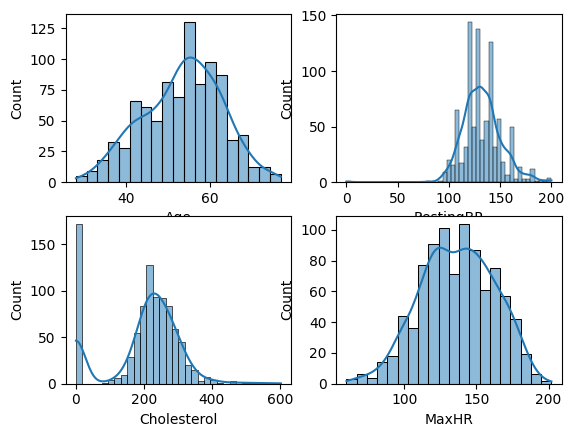

In [17]:
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

In the above graph :
1- in cholesterol we can see we have ome people with zero calories which is not possible in reality so we take the mean and replace all the zeros with the mean 
2- 

In [18]:
# we have many 0 values in cholesterol  so we are filling it with mean  
ch_mean=df1.loc[df1['Cholesterol']!=0,'Cholesterol'].mean()
df1['Cholesterol']=df1['Cholesterol'].replace(0,ch_mean)
df1['Cholesterol']= df1['Cholesterol'].round(2)

In [19]:
# we have many 0 values in restingbp so we are filling it with mean  
rb_mean=df1.loc[df1['RestingBP']!=0,'RestingBP'].mean()
df1['RestingBP']=df1['RestingBP'].replace(0,rb_mean)
df1['RestingBP']=df1['RestingBP'].round(2)


In [20]:
df1.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


 now we will see our categorical data by plotting graphs and then compare it with the output  heart Disease which is also a  categorical data and we can use hue to compare it with different inputs
 


<Axes: xlabel='ChestPainType', ylabel='count'>

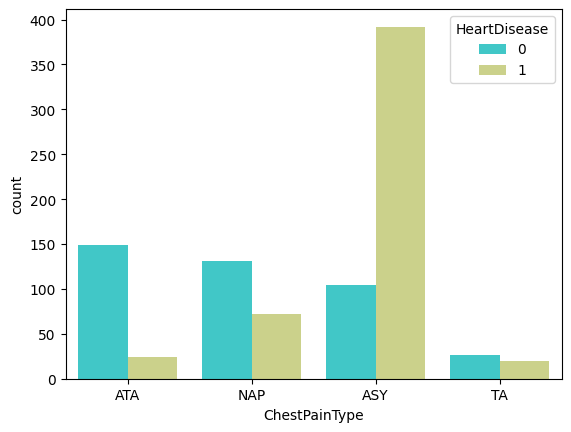

In [21]:
sns.countplot(x=df1['ChestPainType'],hue=df1['HeartDisease'],palette='rainbow')

# agar ksii ko asy hai to uske heart disease ke chance ziada hain aur agar ata hai to kam hai 

<Axes: xlabel='RestingECG', ylabel='count'>

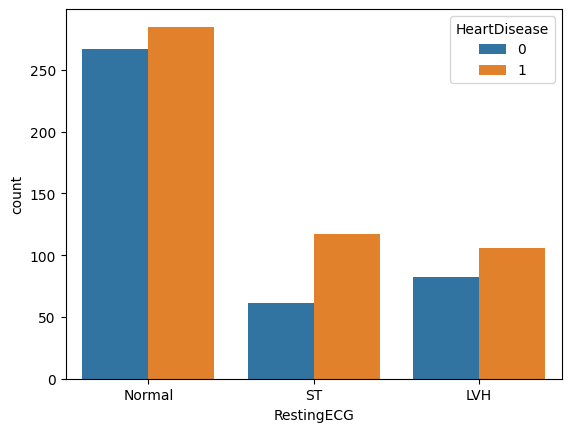

In [22]:
sns.countplot(x=df1['RestingECG'],hue=df1['HeartDisease'])
# agar restingecg normal hai to chance hai ke heart disease hone aur na hone ke chance bhi same hai almost 

now making the box plots because we can compare the categorical output HEART DISEASE with any numerical value

In [23]:
# creating a function so that i dont have to write the syntax again and again just calling the functions for different numeric values with that categorical 
def box_plot(x,y):
    sns.boxplot(x=df1[x],y=df1[y])

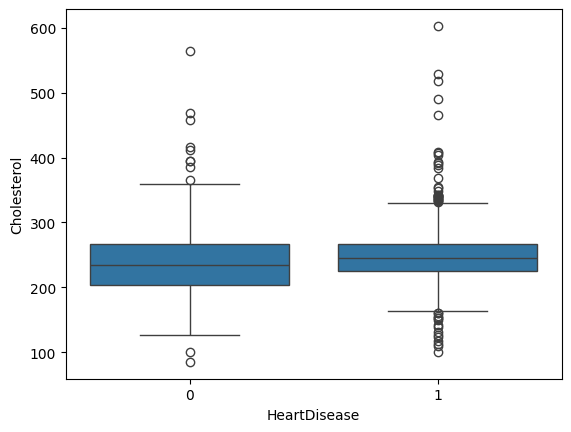

In [24]:
box_plot('HeartDisease','Cholesterol')

<Axes: >

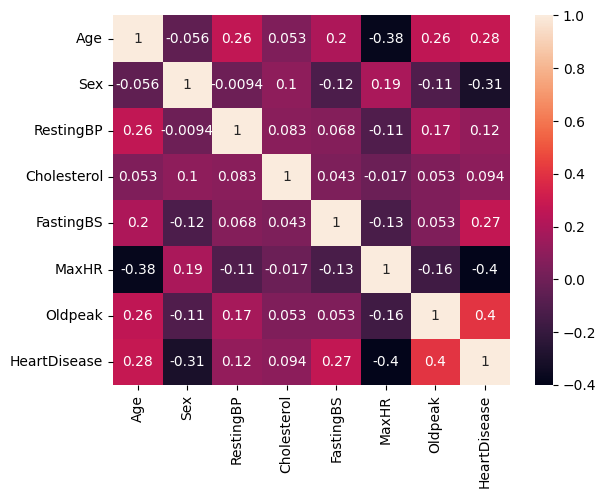

In [25]:
sns.heatmap(df1.corr(numeric_only=True),annot=True)

# Data Preprocessing & Cleaning

In [26]:
df1.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [27]:
df1['Oldpeak']=df1['Oldpeak'].astype(int)

In [28]:
 
 # splitting region into dummy values to convert text into numbers using one hot encoding
df1.columns = df1.columns.str.strip()
df1 = pd.get_dummies(df1, columns=['RestingECG'])

In [29]:
df1.columns=df1.columns.str.strip()
df1=pd.get_dummies(df1,columns=['ChestPainType','ST_Slope'])

In [30]:
df1['RestingECG_LVH']=df1['RestingECG_LVH'].astype(int)
df1['RestingECG_Normal']=df1['RestingECG_Normal'].astype(int)
df1['RestingECG_ST']=df1['RestingECG_ST'].astype(int)
df1['ST_Slope_Down']=df1['ST_Slope_Down'].astype(int)
df1['ST_Slope_Up']=df1['ST_Slope_Up'].astype(int)
df1['ST_Slope_Flat']=df1['ST_Slope_Flat'].astype(int)
df1['ChestPainType_ASY']=df1['ChestPainType_ASY'].astype(int)
df1['ChestPainType_ATA']=df1['ChestPainType_ATA'].astype(int)
df1['ChestPainType_NAP']=df1['ChestPainType_NAP'].astype(int)
df1['ChestPainType_TA']=df1['ChestPainType_TA'].astype(int)

# Feature scaling 

In [31]:
df1.columns

Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [32]:
from sklearn.preprocessing import StandardScaler
cols=['Age','Cholesterol','RestingBP','MaxHR','Oldpeak']
scaler=StandardScaler()
df1[cols]=scaler.fit_transform(df1[cols])


In [33]:
df1['ExerciseAngina']=df1['ExerciseAngina'].map({'N':0,'Y':1})

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [35]:
# Train test split
X=df1.drop('HeartDisease',axis=1)
Y=df1['HeartDisease']

In [36]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=42)


In [37]:
scaler=StandardScaler()
X_train_scales=scaler.fit_transform(X_train)
X_test_scales=scaler.fit_transform(X_test)

In [38]:
models={
    "LogisticRegression":LogisticRegression(),
    "KNN":KNeighborsClassifier(),
    "DecisionTree":DecisionTreeClassifier(),
    "NaiveByes":GaussianNB(),
    "SVM":SVC()
}

In [39]:
result=[]
for name ,model in models.items():
    model.fit(X_train_scales,Y_train)
    Y_pred=model.predict(X_test_scales)
    acc=accuracy_score(Y_test,Y_pred)
    f1=f1_score(Y_test,Y_pred)
    result.append({"model":name,"accuracy":acc,"F1_score":f1})

In [40]:
result

[{'model': 'LogisticRegression',
  'accuracy': 0.875,
  'F1_score': 0.8899521531100478},
 {'model': 'KNN',
  'accuracy': 0.8532608695652174,
  'F1_score': 0.8708133971291866},
 {'model': 'DecisionTree', 'accuracy': 0.8043478260869565, 'F1_score': 0.8125},
 {'model': 'NaiveByes',
  'accuracy': 0.842391304347826,
  'F1_score': 0.8557213930348259},
 {'model': 'SVM', 'accuracy': 0.8586956521739131, 'F1_score': 0.875}]

Saving the models and columns by using pickel and then later on use it 

In [41]:
import joblib as jb
jb.dump(models['LogisticRegression'],'LG_heart.pkl')
jb.dump(scaler,'scaler.pkl')
jb.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']